<h3>Ralph Richmond D. Amariilo</h3>
<h3>Nerjie Angelo Mecantina 
<hr>
<h1>Finals Project: <strong>Family Income and Expenditure</strong></h1>
<hr>
<strong>Course</strong>: Data Analytics with Python

<strong>Instructor</strong>: Leonard Andrew Mesiera  
<strong>Due Date</strong>: November 27, 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [2]:
FIE = pd.read_csv('datasets\\Family Income and Expenditure.csv')
FIE.head()

,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,1,1,0,0,0,2,1,0,0,1
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,1,0,0,0,3,1,0,0,2
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,...,0,0,0,0,0,0,0,0,0,0
3,107589,CAR,78189,Wage/Salaries,0,34030,28659,10914,10812,690,...,0,0,0,0,0,1,0,0,0,0
4,189322,CAR,94625,Wage/Salaries,0,34820,30167,18391,11309,1395,...,1,0,0,0,0,3,0,0,0,1


In [3]:
FIE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41544 entries, 0 to 41543
Data columns (total 60 columns):
 #   Column                                         Non-Null Count  Dtype 
---  ------                                         --------------  ----- 
 0   Total Household Income                         41544 non-null  int64 
 1   Region                                         41544 non-null  object
 2   Total Food Expenditure                         41544 non-null  int64 
 3   Main Source of Income                          41544 non-null  object
 4   Agricultural Household indicator               41544 non-null  int64 
 5   Bread and Cereals Expenditure                  41544 non-null  int64 
 6   Total Rice Expenditure                         41544 non-null  int64 
 7   Meat Expenditure                               41544 non-null  int64 
 8   Total Fish and  marine products Expenditure    41544 non-null  int64 
 9   Fruit Expenditure                              41544 non-null

In [4]:
FIE.isnull().sum()

Total Household Income                              0
Region                                              0
Total Food Expenditure                              0
Main Source of Income                               0
Agricultural Household indicator                    0
Bread and Cereals Expenditure                       0
Total Rice Expenditure                              0
Meat Expenditure                                    0
Total Fish and  marine products Expenditure         0
Fruit Expenditure                                   0
Vegetables Expenditure                              0
Restaurant and hotels Expenditure                   0
Alcoholic Beverages Expenditure                     0
Tobacco Expenditure                                 0
Clothing, Footwear and Other Wear Expenditure       0
Housing and water Expenditure                       0
Imputed House Rental Value                          0
Medical Care Expenditure                            0
Transportation Expenditure  

In [5]:
print("Summary Statistics:")
FIE[['Total Household Income', 'Total Food Expenditure']].describe()

Summary Statistics:


,Total Household Income,Total Food Expenditure
count,4.154400e+04,41544.000000
mean,2.475556e+05,85099.158194
std,2.868805e+05,51637.947682
min,1.128500e+04,2947.000000
25%,1.048950e+05,51017.250000
50%,1.640795e+05,72985.500000
75%,2.911385e+05,105635.500000
max,1.181599e+07,827565.000000


In [6]:
FIE[['Total Household Income', 'Total Food Expenditure']].corr()

,Total Household Income,Total Food Expenditure
Total Household Income,1.00000,0.66366
Total Food Expenditure,0.66366,1.00000


In [7]:
FIE.groupby('Agricultural Household indicator')['Total Food Expenditure'].mean()

Agricultural Household indicator
0     87979.702555
1     60992.419273
2    115966.577149
Name: Total Food Expenditure, dtype: float64

In [8]:
X = FIE[['Total Household Income']]
y = FIE['Total Food Expenditure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Prediction Example (income = 200,000):")
prediction = model.predict(pd.DataFrame({'Total Household Income': [200000]}))
print(prediction)

Prediction Example (income = 200,000):
[79380.00432999]


<hr>
<strong>DESCRIPTIVE ANALYTICS</strong>
<hr>

<h1>Income Distribution</h1>

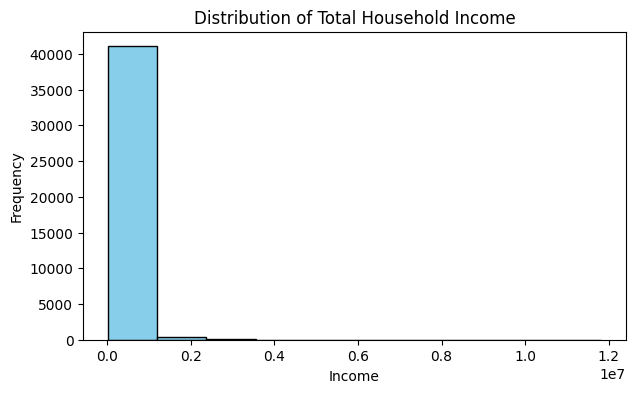

In [10]:
plt.figure(figsize=(7,4))
plt.hist(FIE["Total Household Income"].dropna(), color="skyblue", edgecolor="black")
plt.title("Distribution of Total Household Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

Insight:

Most households fall under the lower to middle-income levels, while only a few households have very high income.
The distribution is <strong>right-skewed</strong>, which is common in real-world income datasets.
<hr>

<h1>Food Expenditure Distribution</h1>

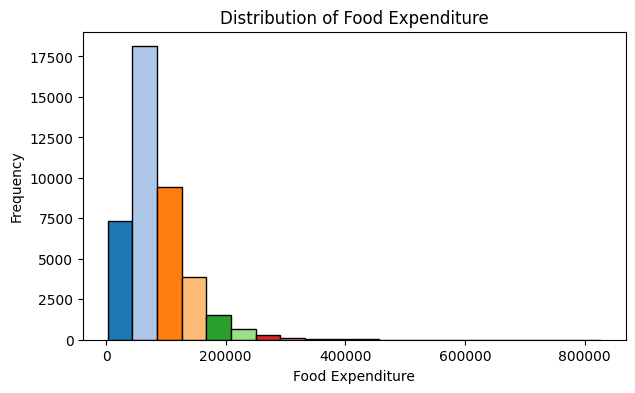

In [30]:
data = FIE["Total Food Expenditure"].dropna()

plt.figure(figsize=(7,4))
counts, bins, patches = plt.hist(data, bins=20, edgecolor='black')

# Apply a unique color for each bar
for patch, color in zip(patches, plt.cm.tab20(np.linspace(0, 1, len(patches)))):
    patch.set_facecolor(color)

plt.title("Distribution of Food Expenditure")
plt.xlabel("Food Expenditure")
plt.ylabel("Frequency")
plt.show()

Insight:

Food spending is also right-skewed most households spend moderately on food, with a small number spending much higher amounts.
This confirms that <strong>food cost scales with income</strong>.
<hr>

<h1>Motorcycle Distribution</h1>

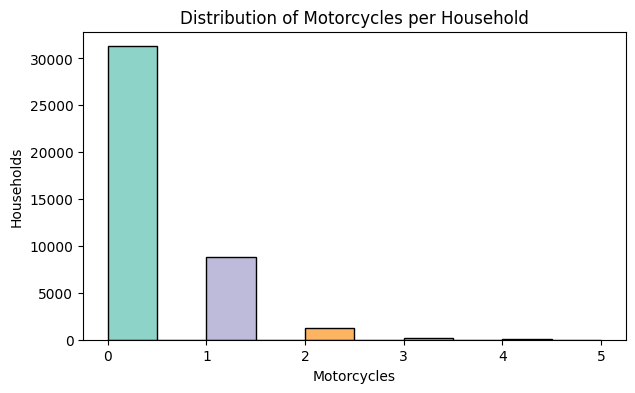

In [31]:
data = FIE["Number of Motorcycle/Tricycle"].dropna()

plt.figure(figsize=(7,4))
counts, bins, patches = plt.hist(data, bins=10, edgecolor='black')

# Apply a unique color to each bar
for patch, color in zip(patches, plt.cm.Set3(np.linspace(0, 1, len(patches)))):
    patch.set_facecolor(color)

plt.title("Distribution of Motorcycles per Household")
plt.xlabel("Motorcycles")
plt.ylabel("Households")
plt.show()

Insight:


Most households own <strong>0 to 1 motorcycle</strong>, showing that motorcycles are somewhat accessible but not universal.
Households with <strong>2+ motorcycles</strong> are uncommon.
<hr>

<h1>PC Ownership</h1>

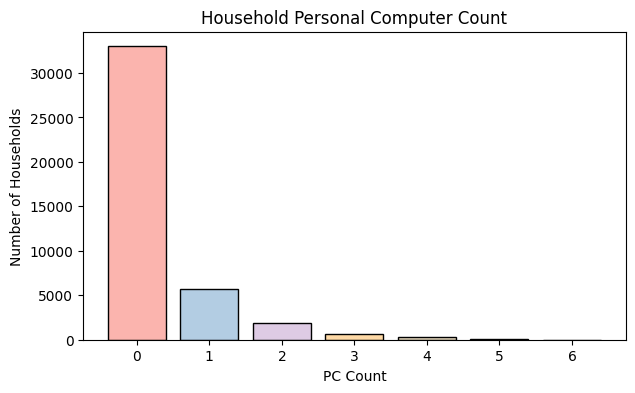

In [32]:
pc_counts = FIE["Number of Personal Computer"].value_counts().sort_index()

plt.figure(figsize=(7,4))

colors = plt.cm.Pastel1(np.linspace(0, 1, len(pc_counts)))

plt.bar(pc_counts.index, pc_counts.values, color=colors, edgecolor="black")
plt.title("Household Personal Computer Count")
plt.xlabel("PC Count")
plt.ylabel("Number of Households")
plt.show()

Insight:

The majority of households own <strong>0 or 1 computer</strong>, suggesting limited digital access.
Higher PC ownership indicates <strong>richer households</strong>.
<hr>

<h1>Average Food Expenditure per Region</h1> 

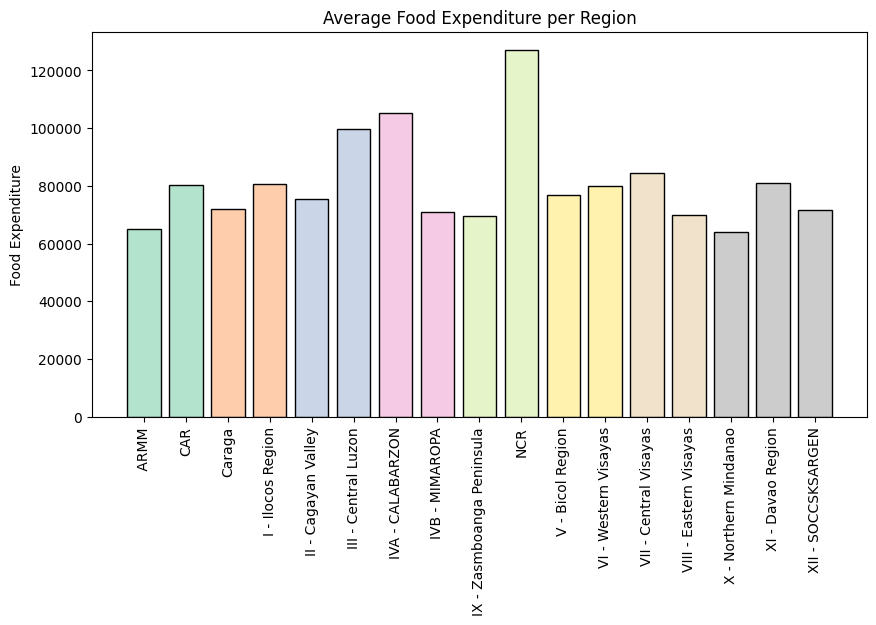

In [33]:
region_avg = FIE.groupby("Region")["Total Food Expenditure"].mean()

plt.figure(figsize=(10,5))

colors = plt.cm.Pastel2(np.linspace(0, 1, len(region_avg)))

plt.bar(region_avg.index, region_avg.values, color=colors, edgecolor="black")
plt.title("Average Food Expenditure per Region")
plt.xticks(rotation=90)
plt.ylabel("Food Expenditure")
plt.show()

<strong>Insight:</strong>

Different regions show very different spending levels.
This may be influenced by:
<ul>
    <li> Cost of living</li>
    <li> Income of the region</li>
    <li> Household size</li>
    <li> Urban vs rural conditions</li>
</ul>

This helps identify <strong>high-cost regions</strong>.
<hr>

<h1>Income Distribution by Region</h1>

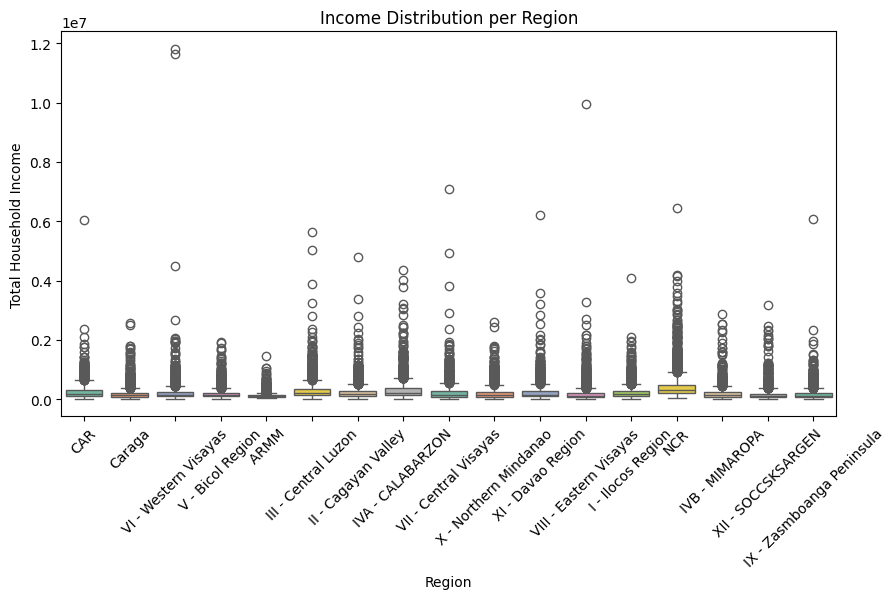

In [35]:
plt.figure(figsize=(10,5))
sns.boxplot(data=FIE,
            x='Region',
            y='Total Household Income',
            hue='Region',
            palette='Set2',
            legend=False)
plt.xticks(rotation=45)
plt.title("Income Distribution per Region")
plt.show()

<h1>Food Expenditure</h1>

<strong>Insight:</strong>

Income levels differ significantly across regions, with some showing much wider ranges, indicating variations in economic opportunities and living standards; <strong>regions with wider boxes and higher medians likely reflect stronger local economies.</strong>
<hr>

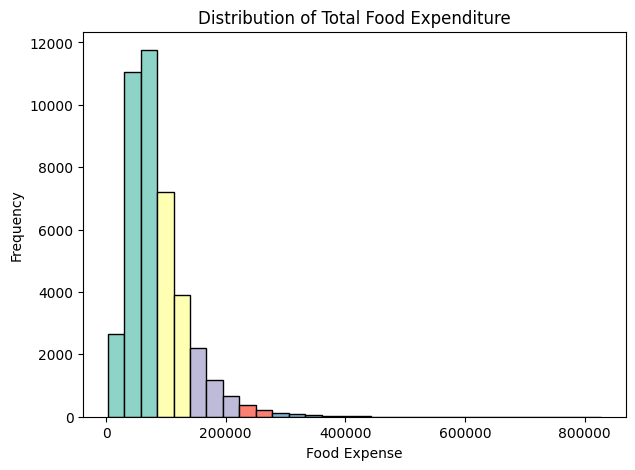

In [36]:
data = FIE['Total Food Expenditure'].dropna()

plt.figure(figsize=(7,5))
counts, bins, patches = plt.hist(data, bins=30, edgecolor='black')

for patch, color in zip(patches, plt.cm.Set3(np.linspace(0, 1, len(patches)))):
    patch.set_facecolor(color)

plt.title("Distribution of Total Food Expenditure")
plt.xlabel("Food Expense")
plt.ylabel("Frequency")
plt.show()

<strong>Insight:</strong>

Food spending is concentrated at lower amounts, with only a small group spending much higher, indicating that most families follow modest food budgets; <strong>the right skew suggests that these higher spending levels occur mainly among higher-income or larger households</strong>.
<hr>

<h1>Bar Chart of Average Food Expenditure by Region</h1>

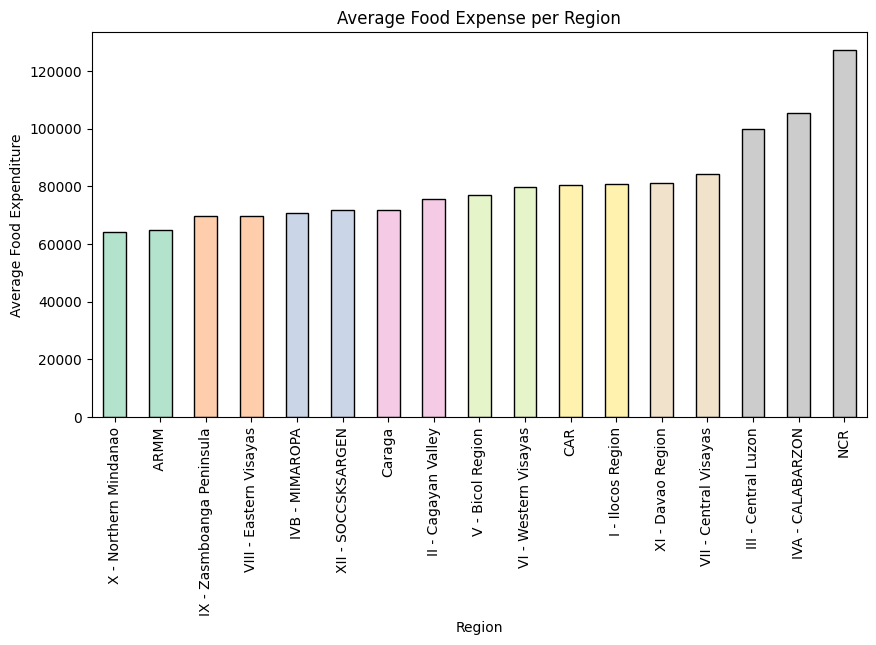

In [37]:
avg_food = FIE.groupby('Region')['Total Food Expenditure'].mean().sort_values()

colors = plt.cm.Pastel2(np.linspace(0, 1, len(avg_food)))

plt.figure(figsize=(10,5))
avg_food.plot(kind='bar', color=colors, edgecolor='black')
plt.title("Average Food Expense per Region")
plt.ylabel("Average Food Expenditure")
plt.show()

<strong>Insight:</strong>

Some regions spend consistently more on food, possibly due to higher costs of living or stronger purchasing power, <strong>with regional gaps revealing where food prices or income levels may differ.</strong>
<hr>

<h1>Countplot of Highest Education Level</h1>

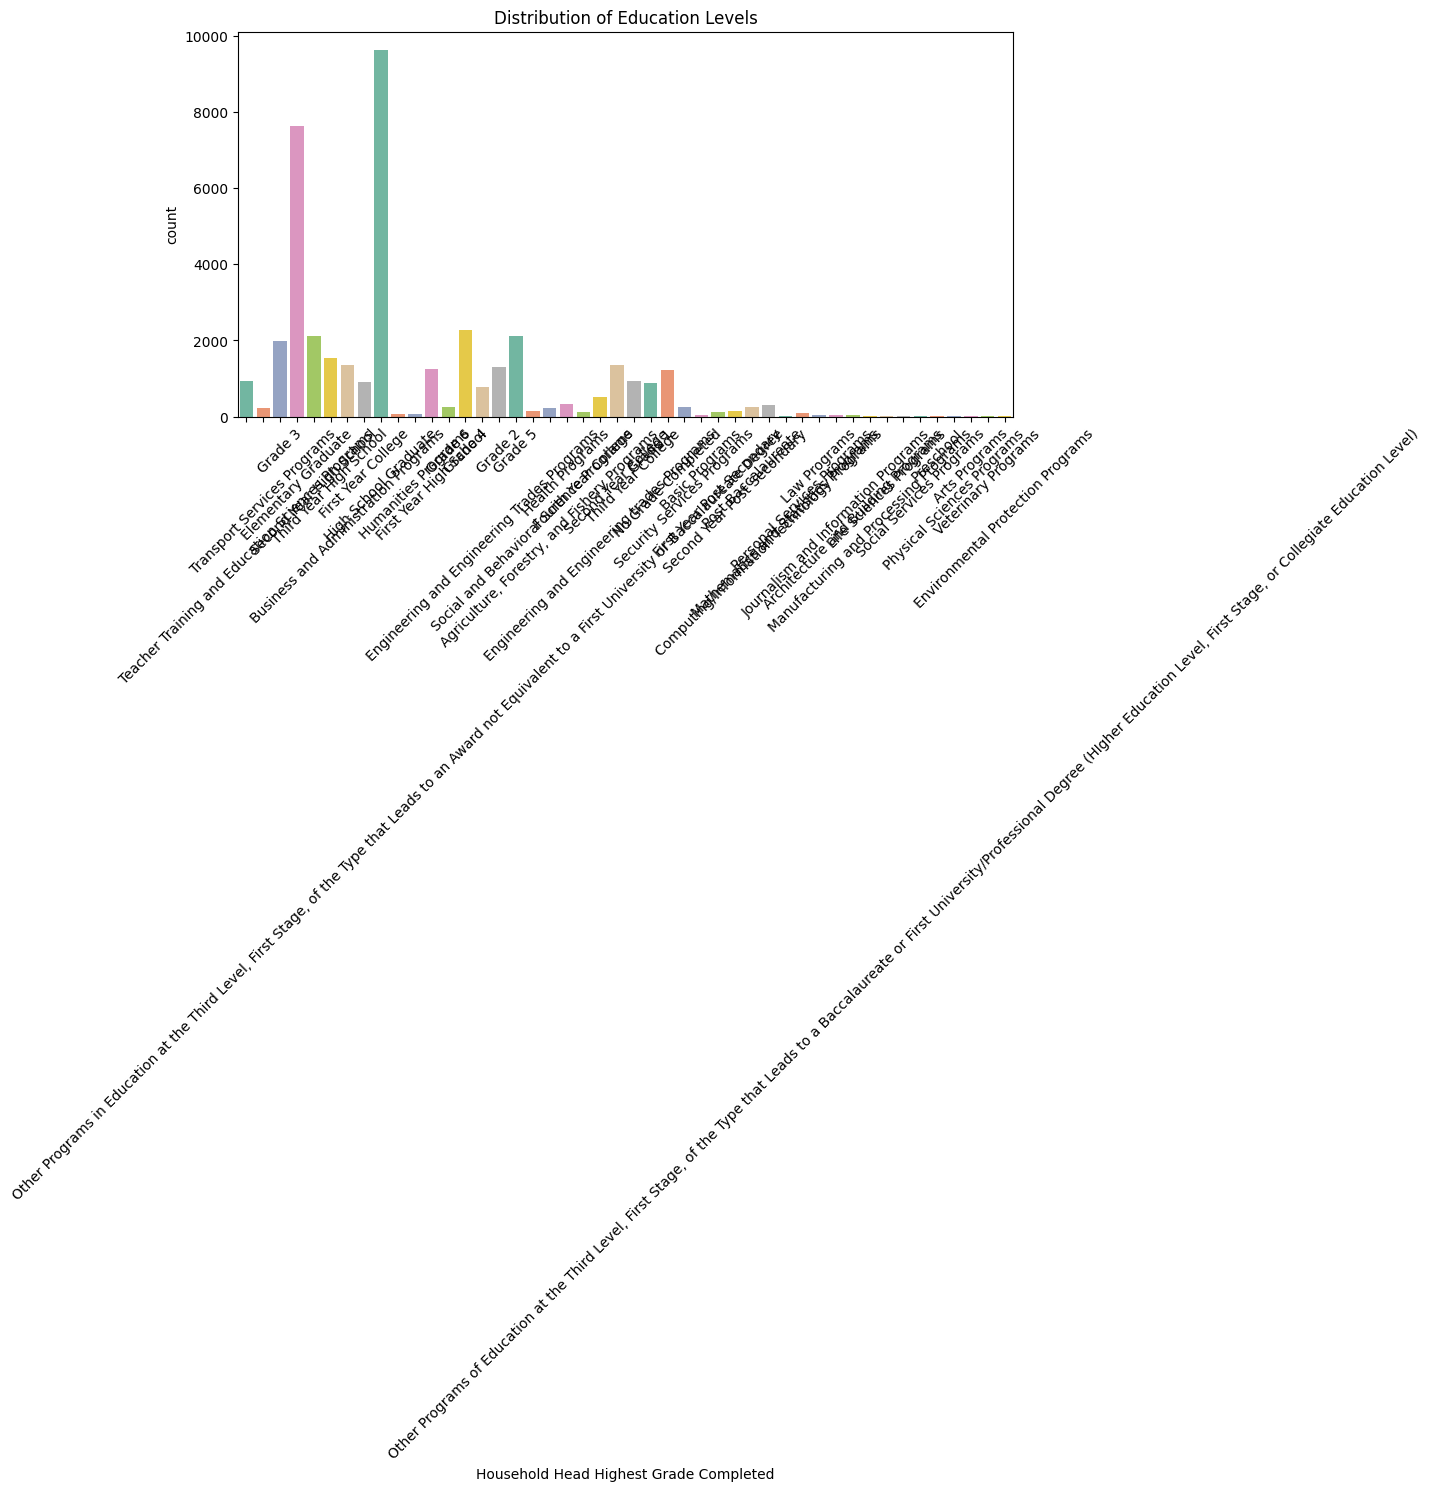

In [39]:
plt.figure(figsize=(10,5))
sns.countplot(
    x='Household Head Highest Grade Completed',
    data=FIE,
    hue='Household Head Highest Grade Completed',
    palette='Set2',
    legend=False
)
plt.title("Distribution of Education Levels")
plt.xticks(rotation=45)
plt.show()

<strong>Insight:</strong>

The majority of households have lower to mid-level education, while higher education levels are less common. This suggests that most heads of households may have limited formal schooling, which could

<hr>
<strong>DIAGNOSTIC ANALYTICS</strong>
<hr>

<h1>Income vs Expenditure with Trendline</h1>

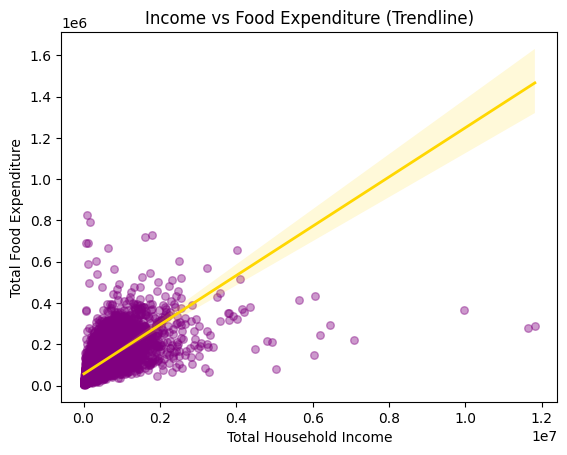

In [40]:
sns.regplot(x='Total Household Income', 
            y='Total Food Expenditure', 
            data=FIE,
            scatter_kws={'color':'purple', 'alpha':0.4, 's':30},
            line_kws={'color':'gold', 'linewidth':2})
plt.title("Income vs Food Expenditure (Trendline)")
plt.xlabel("Total Household Income")
plt.ylabel("Total Food Expenditure")
plt.show()

<strong>Insight:</strong>

Food spending increases with income, but not drastically. Households earning more do spend more, but the increase is gradual.
<strong>Supports Engel’s Law food spending rises slower than income.</strong>
<hr>

<h1>Household Size vs Food Expenditure</h1>

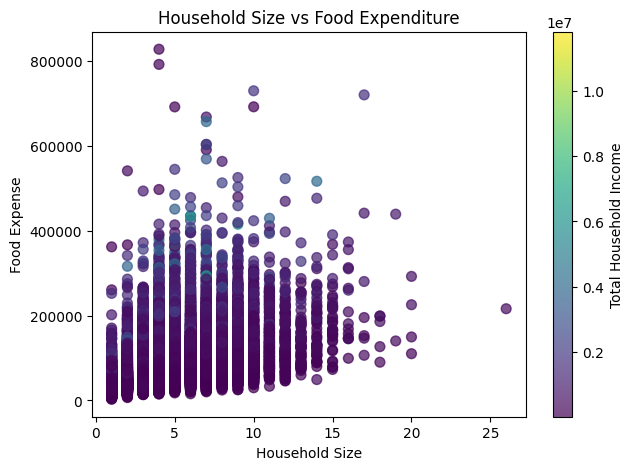

In [43]:
plt.figure(figsize=(7,5))
plt.scatter(FIE['Total Number of Family members'], 
            FIE['Total Food Expenditure'],
            c=FIE['Total Household Income'], cmap='viridis',
            s=50, alpha=0.7)
plt.colorbar(label='Total Household Income')
plt.title("Household Size vs Food Expenditure")
plt.xlabel("Household Size")
plt.ylabel("Food Expense")
plt.show()

<strong>Insight:</strong>

As household size increases, food spending generally rises, confirming that consumption needs scale with more family members; <strong>the clear upward pattern indicates a predictable growth in food costs.</strong>
<hr>

<h1>Correlation Heatmap</h1>

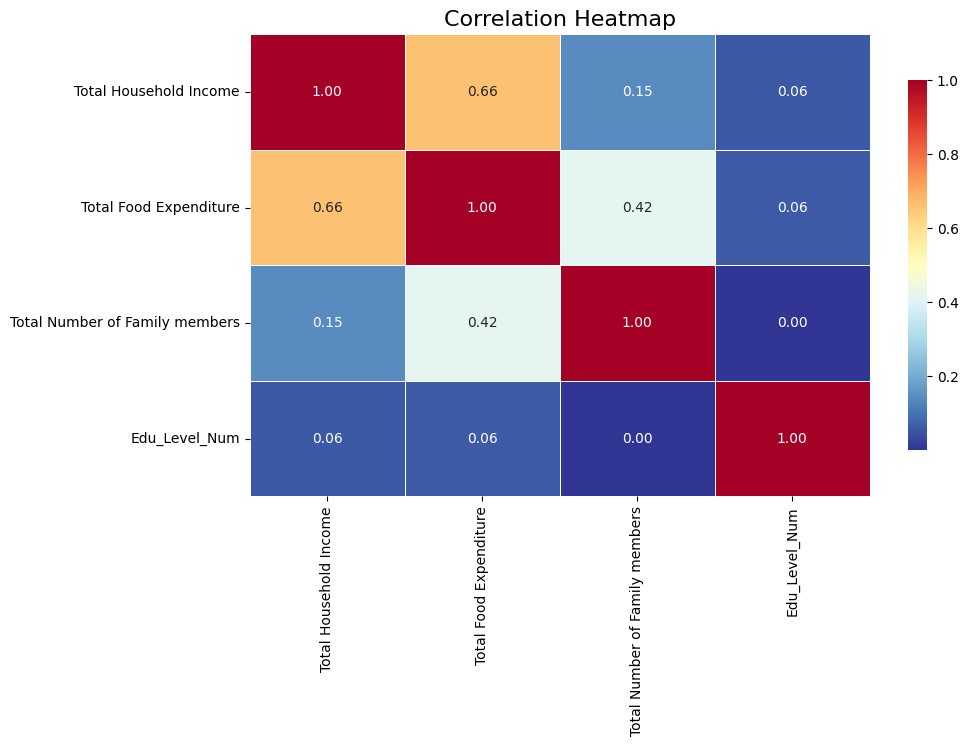

In [44]:
plt.figure(figsize=(10,6))

corr_matrix = FIE[['Total Household Income',
                   'Total Food Expenditure',
                   'Total Number of Family members',
                   'Edu_Level_Num']].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f",               
            cmap='RdYlBu_r',        
            linewidths=0.5,          
            linecolor='white',
            cbar_kws={'shrink':0.8}) 

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

<strong>Insight:</strong>

Income, education, and food expenditure show noticeable positive relationships, helping identify which socioeconomic factors influence spending behavior; <strong>higher education levels correspond to higher income, which in turn affects expenditure.</strong>
<hr>

<h1>Income vs Food Expenditure</h1>

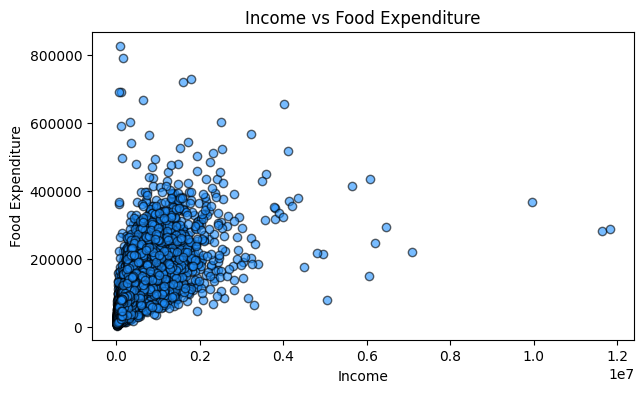

In [46]:
plt.figure(figsize=(7,4))
plt.scatter(FIE["Total Household Income"], FIE["Total Food Expenditure"],
            color='dodgerblue', alpha=0.6, edgecolor='black')
plt.title("Income vs Food Expenditure")
plt.xlabel("Income")
plt.ylabel("Food Expenditure")
plt.show()

<strong>Insight:</strong>


A clear upward pattern shows that <strong>as income increases, food expenditure also increases.</strong>
This confirms a <strong>positive correlation</strong> between income and spending habits.
<hr>

<h1>Income vs Rice Expenditure</h1>

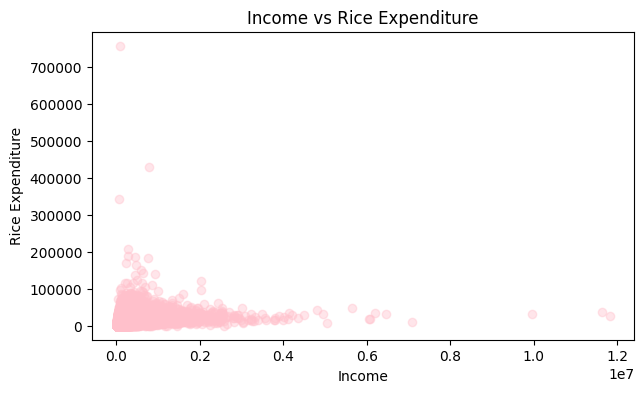

In [48]:
plt.figure(figsize=(7,4))
plt.scatter(FIE["Total Household Income"], FIE["Total Rice Expenditure"],
            color='pink', alpha=0.4)
plt.title("Income vs Rice Expenditure")
plt.xlabel("Income")
plt.ylabel("Rice Expenditure")
plt.show()

<strong>Insight:</strong>

Higher income households tend to spend more on rice, but the increase is not as strong as total food spending.
This suggests:
<ul>
    <li> Rice is a staple food for all income groups. </li>
    <li> Higher income households diversify their diets more.</li>
    <li> Food expenditure patterns are consistent across groups.</li>
</ul>
<hr>

<h1>Meat vs Bread & Cereals Expenditure</h1>

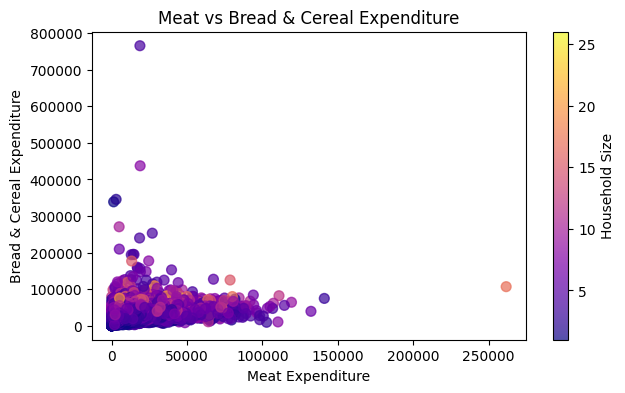

In [49]:
plt.figure(figsize=(7,4))
plt.scatter(FIE["Meat Expenditure"], FIE["Bread and Cereals Expenditure"],
            c=FIE["Total Number of Family members"], cmap='plasma',
            alpha=0.7, s=50)
plt.colorbar(label='Household Size')
plt.title("Meat vs Bread & Cereal Expenditure")
plt.xlabel("Meat Expenditure")
plt.ylabel("Bread & Cereal Expenditure")
plt.show()

<strong>Insight:</strong>

Households that spend more on meat also spend more on bread & cereals.
This indicates:

<ul>
    <li> Households with greater disposable income buy more across all food categories. </li>
    <li> Food expenditure patterns are consistent across groups.</li>
</ul>
<hr>

<h1>Income by Agricultural Household Type</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 700x400 with 0 Axes>

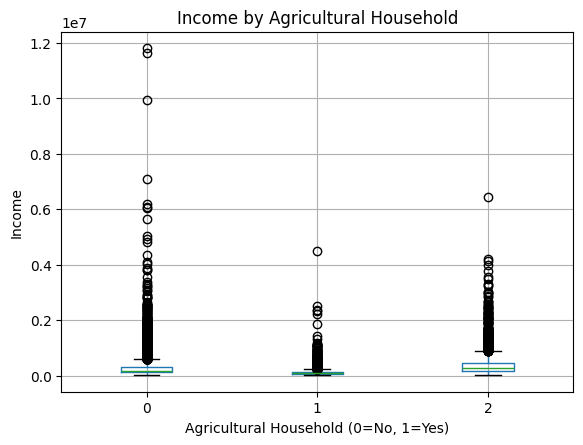

In [56]:
plt.figure(figsize=(7,4))
FIE.boxplot(column="Total Household Income", by="Agricultural Household indicator")
plt.title("Income by Agricultural Household")
plt.suptitle("")
plt.xlabel("Agricultural Household (0=No, 1=Yes)")
plt.ylabel("Income")
plt.show

<strong>Insight:</strong>

Agricultural households generally have lower median income and wider variability.
This suggests:
<ul>
    <li> Agricultural families earn less than non-agricultural families. </li>
    <li> Farming income is less stable or predictable.</li>
</ul>
<hr>

<h1>Food Expenditure vs Number of Earners</h1>

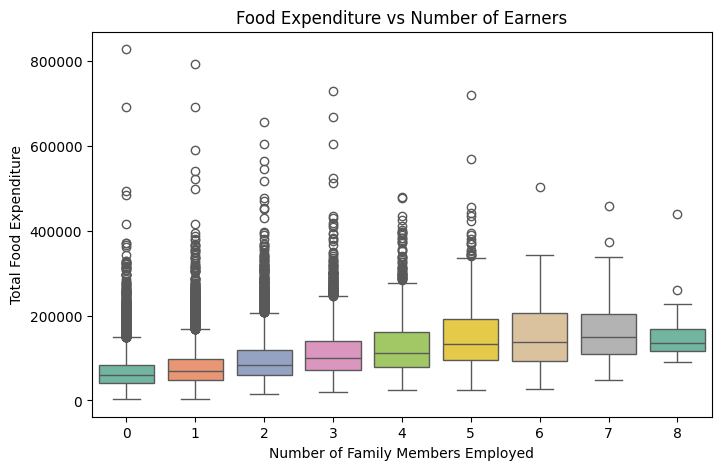

In [58]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=FIE,
    x='Total number of family members employed',
    y='Total Food Expenditure',
    hue='Total number of family members employed',
    palette='Set2',
    legend=False  
)
plt.title("Food Expenditure vs Number of Earners")
plt.xlabel("Number of Family Members Employed")
plt.ylabel("Total Food Expenditure")
plt.show()

<strong>Insight:</strong>

Food expenditure generally increases with the number of earners, suggesting that households with more income contributors tend to spend more on food, though the increase varies across households.

<hr>
<strong>PREDICTIVE ANALYTICS</strong>
<hr>

<h1>Train/Test Performance</h1>

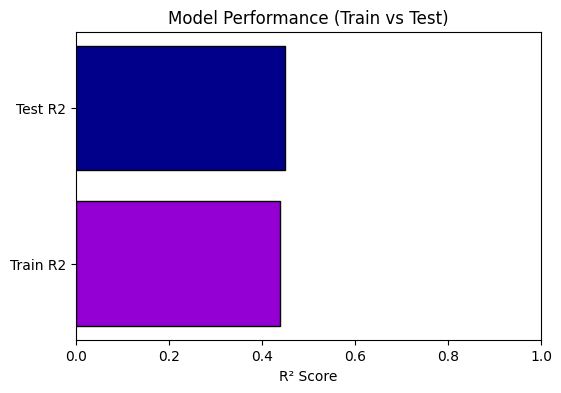

In [64]:
plt.figure(figsize=(6,4))
plt.barh(list(metrics.keys()), list(metrics.values()), color=['darkviolet','darkblue'], edgecolor='black')
plt.title("Model Performance (Train vs Test)")
plt.xlabel("R² Score")
plt.xlim(0,1)
plt.show()

<strong>Insight:</strong>

Evaluates potential overfitting or underfitting by comparing model performance on training and testing datasets.
<hr>

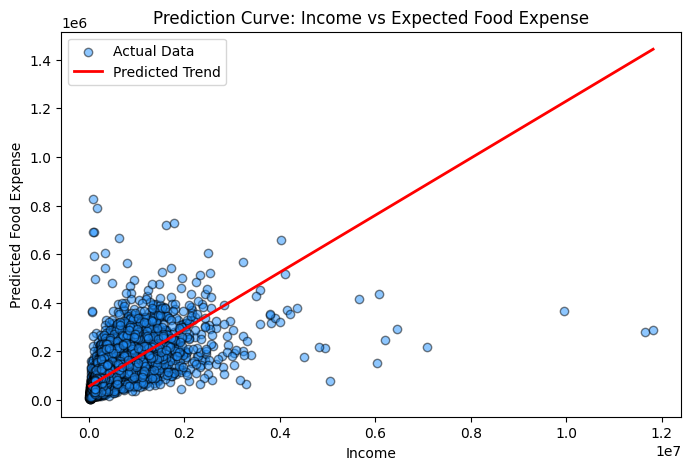

In [66]:
plt.figure(figsize=(8,5))

# Scatter points
plt.scatter(FIE['Total Household Income'], 
            FIE['Total Food Expenditure'], 
            color='dodgerblue', alpha=0.5, label='Actual Data', edgecolor='black')

# Prediction line
plt.plot(income_range, prediction, color='red', linewidth=2, label='Predicted Trend')

plt.title("Prediction Curve: Income vs Expected Food Expense")
plt.xlabel("Income")
plt.ylabel("Predicted Food Expense")
plt.legend()
plt.show()

<strong>Insight</strong>

This illustrates how predicted food expenses change across income levels, <strong>showing that food spending rises gradually as income increases.</strong>
<hr>

<h1>Predictive Trend Line (Income → Food Expenditure)</h1>

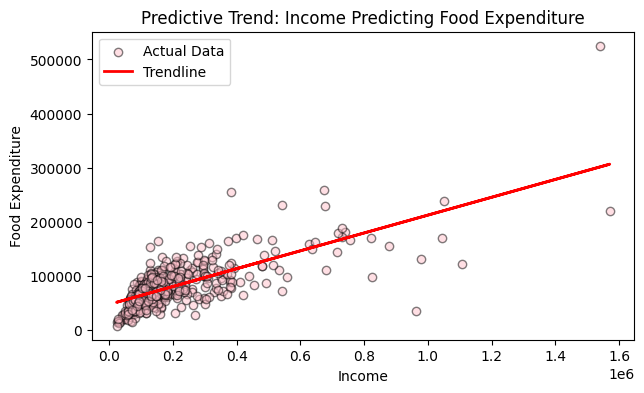

In [68]:
income = FIE["Total Household Income"].dropna().iloc[:500]
food = FIE["Total Food Expenditure"].dropna().iloc[:500]

# Fit a linear trend
m, b = np.polyfit(income, food, 1)

plt.figure(figsize=(7,4))

# Scatter points
plt.scatter(income, food, color='pink', alpha=0.5, edgecolor='black', label='Actual Data')

# Trendline
plt.plot(income, m*income + b, color='red', linewidth=2, label='Trendline')

plt.title("Predictive Trend: Income Predicting Food Expenditure")
plt.xlabel("Income")
plt.ylabel("Food Expenditure")
plt.legend()
plt.show()

<strong>Insight:</strong>

A regression line shows a strong linear trend:
<strong>Higher income → Higher food spending</strong>

This model can be used to <strong>predict future or unknown food expenditures</strong> based on income.